In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

eda_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "DISTANCE",
    "DEP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "DELAY_CLASS",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "PREV_FLIGHT_DELAY",
    "HAS_PREV_FLIGHT",
    "AIRPORT_TRAFFIC",
    "IS_HOLIDAY",
]
df = pd.read_parquet("data/combined_preprocessed.parquet", columns=eda_cols)
print(df.shape)
df.head()


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898737 entries, 0 to 6898736
Data columns (total 15 columns):
 #   Column               Dtype  
---  ------               -----  
 0   DEP_DELAY            float64
 1   DEP_DEL15            float64
 2   DISTANCE             float64
 3   DEP_HOUR             int64  
 4   DAY_OF_WEEK          int64  
 5   MONTH                int64  
 6   DELAY_CLASS          int64  
 7   WEATHER_DELAY        float64
 8   NAS_DELAY            float64
 9   SECURITY_DELAY       float64
 10  LATE_AIRCRAFT_DELAY  float64
 11  PREV_FLIGHT_DELAY    float64
 12  HAS_PREV_FLIGHT      int64  
 13  AIRPORT_TRAFFIC      int64  
 14  IS_HOLIDAY           int64  
dtypes: float64(8), int64(7)
memory usage: 789.5 MB


In [3]:
df.describe()

,DEP_DELAY,DEP_DEL15,DISTANCE,DEP_HOUR,DAY_OF_WEEK,MONTH,DELAY_CLASS,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,AIRPORT_TRAFFIC,IS_HOLIDAY
count,6.898737e+06,6.898737e+06,6.898737e+06,6.898737e+06,6.898737e+06,6.898737e+06,6.898737e+06,1.534635e+06,1.534635e+06,1.534635e+06,1.534635e+06,6.898737e+06,6.898737e+06,6.898737e+06,6.898737e+06
mean,1.351155e+01,2.173082e-01,8.464216e+02,1.295262e+01,3.996670e+00,6.575791e+00,2.665326e-01,4.632186e+00,1.595411e+01,9.956895e-02,2.858178e+01,3.660643e+00,7.489835e-01,9.173086e+00,8.424209e-02
std,5.740149e+01,4.124141e-01,6.029936e+02,4.884438e+00,2.010053e+00,3.389226e+00,5.421639e-01,3.481620e+01,3.641470e+01,3.336256e+00,6.176752e+01,4.154609e+01,4.335980e-01,2.656649e+00,2.777506e-01
min,-1.150000e+02,0.000000e+00,3.100000e+01,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.280000e+02,0.000000e+00,1.000000e+00,0.000000e+00
25%,-6.000000e+00,0.000000e+00,4.040000e+02,9.000000e+00,2.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.300000e+01,0.000000e+00,9.000000e+00,0.000000e+00
50%,-2.000000e+00,0.000000e+00,6.950000e+02,1.300000e+01,4.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+01,0.000000e+00
75%,1.000000e+01,0.000000e+00,1.084000e+03,1.700000e+01,6.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,1.900000e+01,0.000000e+00,3.300000e+01,1.000000e+00,1.000000e+00,1.100000e+01,0.000000e+00
max,4.352000e+03,1.000000e+00,5.095000e+03,2.400000e+01,7.000000e+00,1.200000e+01,2.000000e+00,2.394000e+03,1.706000e+03,9.900000e+02,2.425000e+03,3.500000e+03,1.000000e+00,1.300000e+01,1.000000e+00


---
## 1. Target Distribution & Class Imbalance

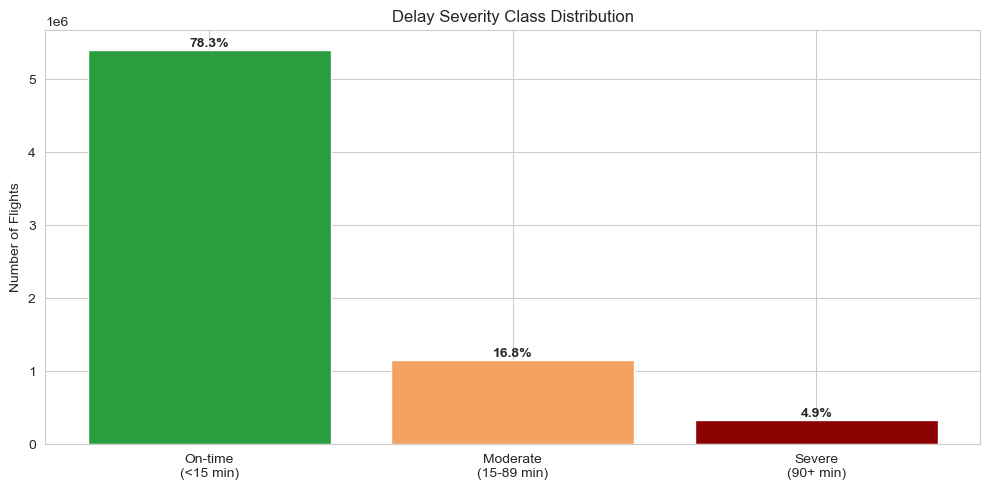

DELAY_CLASS
0    78.27
1    16.81
2     4.92
Name: count, dtype: float64


In [ ]:
class_counts = df["DELAY_CLASS"].value_counts().sort_index()
class_labels = [
    "On-time\n(<15 min)",
    "Moderate\n(15-89 min)",
    "Severe\n(90+ min)",
]
class_pct = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    class_labels,
    class_counts.values,
    color=["#2a9d3f", "#F4A261", "#8B0000"],
)
ax.set_ylabel("Number of Flights")
ax.set_title("Delay Severity Class Distribution")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in class_pct], fontweight="bold")
plt.tight_layout()
plt.show()

print(class_pct.round(2))


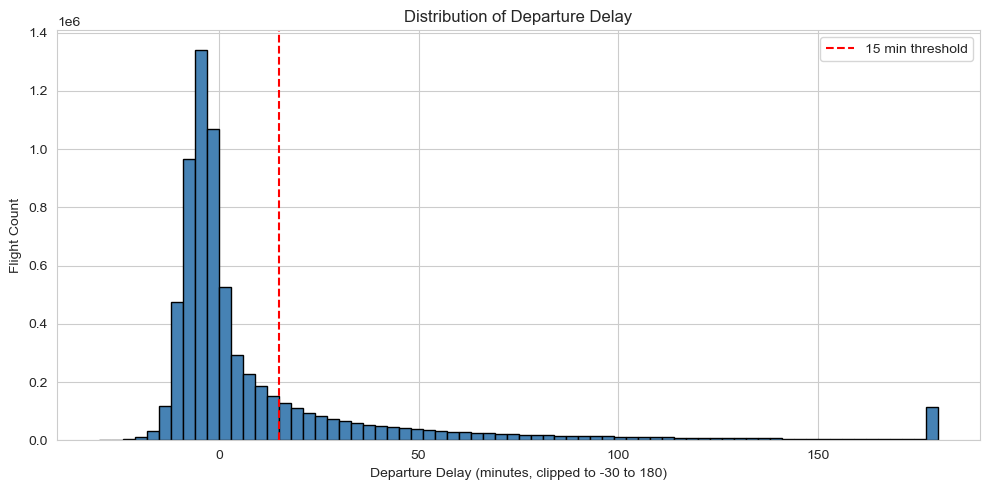

count    6898737.0
mean          13.5
std           57.4
min         -115.0
50%           -2.0
95%           89.0
max         4352.0
Name: DEP_DELAY, dtype: float64


In [ ]:
clipped = df["DEP_DELAY"].clip(-30, 180)
plt.figure(figsize=(10, 5))
plt.hist(clipped, bins=70, color="steelblue", edgecolor="black")
plt.axvline(15, color="red", linestyle="--", label="15 min threshold")
plt.xlabel("Departure Delay (minutes, clipped to -30 to 180)")
plt.ylabel("Flight Count")
plt.title("Distribution of Departure Delay")
plt.legend()
plt.tight_layout()
plt.show()

print(df["DEP_DELAY"].describe(percentiles=[0.5, 0.95]).round(1))


---
## 2. Carrier Analysis

Which airlines delay the most? Do different carriers get delayed for different reasons?

In [ ]:
cols = [
    "OP_UNIQUE_CARRIER",
    "DEP_DEL15",
    "DEP_DELAY",
    "CANCELLED",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
]
df_car = pd.read_parquet("data/combined_new.parquet", columns=cols)
df_car = df_car[df_car["CANCELLED"] != 1].copy()

carrier_names = {
    "AA": "American",
    "AS": "Alaska",
    "B6": "JetBlue",
    "DL": "Delta",
    "F9": "Frontier",
    "G4": "Allegiant",
    "HA": "Hawaiian",
    "MQ": "Envoy",
    "NK": "Spirit",
    "OH": "PSA",
    "OO": "SkyWest",
    "UA": "United",
    "WN": "Southwest",
    "YX": "Republic",
    "9E": "Endeavor",
    "YV": "Mesa",
    "EV": "ExpressJet",
    "VX": "Virgin America",
}
df_car["carrier"] = (
    df_car["OP_UNIQUE_CARRIER"].map(carrier_names).fillna(df_car["OP_UNIQUE_CARRIER"])
)

agg = df_car.groupby("carrier").agg(
    n_flights=("DEP_DEL15", "size"),
    delay_rate=("DEP_DEL15", "mean"),
    avg_dep_delay=("DEP_DELAY", "mean"),
    carrier_delay=("CARRIER_DELAY", "sum"),
    weather_delay=("WEATHER_DELAY", "sum"),
    nas_delay=("NAS_DELAY", "sum"),
    security_delay=("SECURITY_DELAY", "sum"),
    late_aircraft_delay=("LATE_AIRCRAFT_DELAY", "sum"),
)
agg["delay_rate_pct"] = agg["delay_rate"] * 100

reason_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
]
totals = agg[reason_cols].sum(axis=1).replace(0, np.nan)
reason_pct = agg[reason_cols].div(totals, axis=0) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Carrier Delay Analysis", fontsize=16, fontweight="bold", y=1.00)

ax = axes[0, 0]
d = agg["delay_rate_pct"].sort_values()
bars = ax.barh(d.index, d.values, color="steelblue")
ax.set_title("1. Delay Rate by Carrier (% flights ≥15 min late)")
ax.set_xlabel("% of flights delayed")
for bar, v in zip(bars, d.values):
    ax.text(
        v + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%",
        va="center",
        fontsize=9,
    )

ax = axes[0, 1]
d = agg["avg_dep_delay"].sort_values()
med = d.median()
colors = [
    "#2a9d3f" if v < 0 else "steelblue" if v < med else "indianred" for v in d.values
]
bars = ax.barh(d.index, d.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("2. Average Departure Delay (minutes)")
ax.set_xlabel("Average DEP_DELAY — negative = on average early")
for bar, v in zip(bars, d.values):
    ax.text(
        v + (0.15 if v >= 0 else -0.15),
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
    )

ax = axes[1, 0]
order = agg["delay_rate_pct"].sort_values(ascending=False).index
plot_df = reason_pct.loc[order].copy()
plot_df.columns = [
    "Carrier",
    "Weather",
    "NAS (Air Traffic)",
    "Security",
    "Late Aircraft",
]
plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"],
    width=0.8,
)
ax.set_title("3. Delay-Minute Breakdown by Cause (%)")
ax.set_xlabel("% of total delay minutes")
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax.invert_yaxis()

ax = axes[1, 1]
d = (agg["n_flights"] / 1e6).sort_values()
bars = ax.barh(d.index, d.values, color="slategray")
ax.set_title("4. Flight Volume by Carrier")
ax.set_xlabel("Flights (millions)")
for bar, v in zip(bars, d.values):
    ax.text(
        v + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.2f}M",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [7]:
print("=== Summary (sorted by delay rate, best → worst) ===")
summary = agg[["n_flights", "delay_rate_pct", "avg_dep_delay"]].sort_values(
    "delay_rate_pct"
)
summary["n_flights"] = summary["n_flights"].map(lambda x: f"{x:>10,}")
print(summary.to_string(float_format="%.2f"))

print("\n=== Delay-cause mix, % of delay minutes (worst carrier first) ===")
print(reason_pct.loc[order].round(1).to_string())

best = agg["delay_rate_pct"].idxmin()
worst = agg["delay_rate_pct"].idxmax()
print(
    f"\nMost reliable: {best}  ({agg.loc[best, 'delay_rate_pct']:.1f}% delayed, "
    f"avg {agg.loc[best, 'avg_dep_delay']:.1f} min)"
)
print(
    f"Worst:         {worst} ({agg.loc[worst, 'delay_rate_pct']:.1f}% delayed, "
    f"avg {agg.loc[worst, 'avg_dep_delay']:.1f} min)"
)


=== Summary (sorted by delay rate, best → worst) ===
            n_flights  delay_rate_pct  avg_dep_delay
carrier                                             
Hawaiian       79,424           15.23           7.84
Republic      334,738           18.01           9.88
Envoy         292,609           18.44           9.26
SkyWest       827,978           18.45          12.66
United        788,743           19.09          12.21
Delta       1,015,218           19.41          11.58
Alaska        242,614           20.86           8.20
Spirit        191,583           21.45          12.84
Allegiant     130,284           23.38          15.30
Southwest   1,380,086           24.61          12.81
American      955,974           25.11          18.95
JetBlue       227,588           25.19          16.50
PSA           237,341           25.64          20.81
Frontier      194,557           26.96          19.38

=== Delay-cause mix, % of delay minutes (worst carrier first) ===
           carrier_delay  weathe

---
## 3. Time Patterns

When do delays happen? Morning vs evening, weekday vs weekend, seasonal patterns.

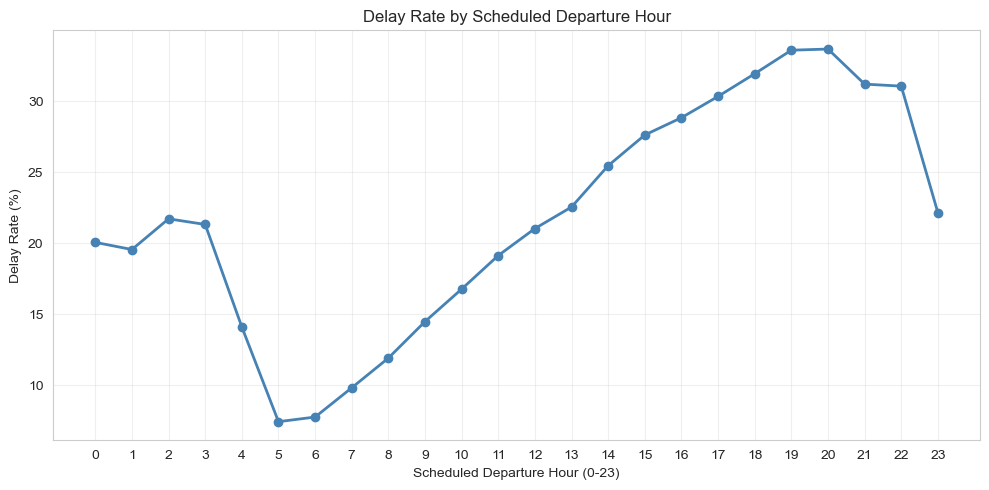

Best hour:   5:00  (7.4% delayed)
Worst hour: 20:00  (33.7% delayed)


In [ ]:
hour_delay = df[df["DEP_HOUR"] < 24].groupby("DEP_HOUR")["DEP_DEL15"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(
    hour_delay.index, hour_delay.values, marker="o", linewidth=2, color="steelblue"
)
plt.xlabel("Scheduled Departure Hour (0-23)")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Scheduled Departure Hour")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best hour:  {hour_delay.idxmin():>2}:00  ({hour_delay.min():.1f}% delayed)")
print(f"Worst hour: {hour_delay.idxmax():>2}:00  ({hour_delay.max():.1f}% delayed)")


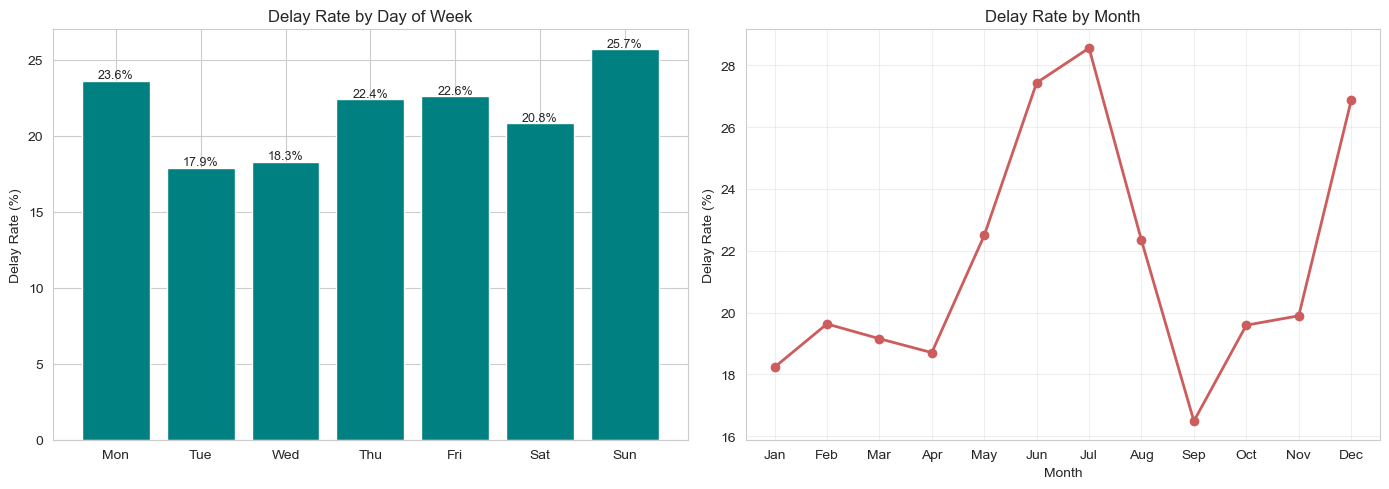

In [ ]:
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_delay = df.groupby("DAY_OF_WEEK")["DEP_DEL15"].mean() * 100
month_delay = df.groupby("MONTH")["DEP_DEL15"].mean() * 100
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_labels, dow_delay.values, color="teal")
axes[0].set_ylabel("Delay Rate (%)")
axes[0].set_title("Delay Rate by Day of Week")
for i, v in enumerate(dow_delay.values):
    axes[0].text(i, v + 0.15, f"{v:.1f}%", ha="center", fontsize=9)

axes[1].plot(
    month_delay.index, month_delay.values, marker="o", linewidth=2, color="indianred"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Delay Rate (%)")
axes[1].set_title("Delay Rate by Month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 4. Geography & Distance

Where do delays happen, and does flight distance matter?

In [ ]:
df_raw = pd.read_parquet(
    "data/combined_new.parquet",
    columns=[
        "CANCELLED",
        "DEP_DELAY",
        "ORIGIN_CITY_NAME",
        "DEST_CITY_NAME",
        "CARRIER_DELAY",
        "WEATHER_DELAY",
        "NAS_DELAY",
        "SECURITY_DELAY",
        "LATE_AIRCRAFT_DELAY",
    ],
)
df_raw = df_raw[df_raw["CANCELLED"] == 0].dropna(subset=["DEP_DELAY"])
df_raw["DELAYED"] = (df_raw["DEP_DELAY"] >= 15).astype(int)

city_stats = df_raw.groupby("ORIGIN_CITY_NAME")["DELAYED"].agg(["mean", "count"])
top_cities = city_stats[city_stats["count"] >= 50000].nlargest(10, "mean")

plt.figure(figsize=(10, 5))
plt.barh(top_cities.index, top_cities["mean"] * 100, color="steelblue")
plt.xlabel("Delay Rate (%)")
plt.title("Top 10 Origin Cities by Delay Rate (≥15 min, min 50k flights)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_cities)


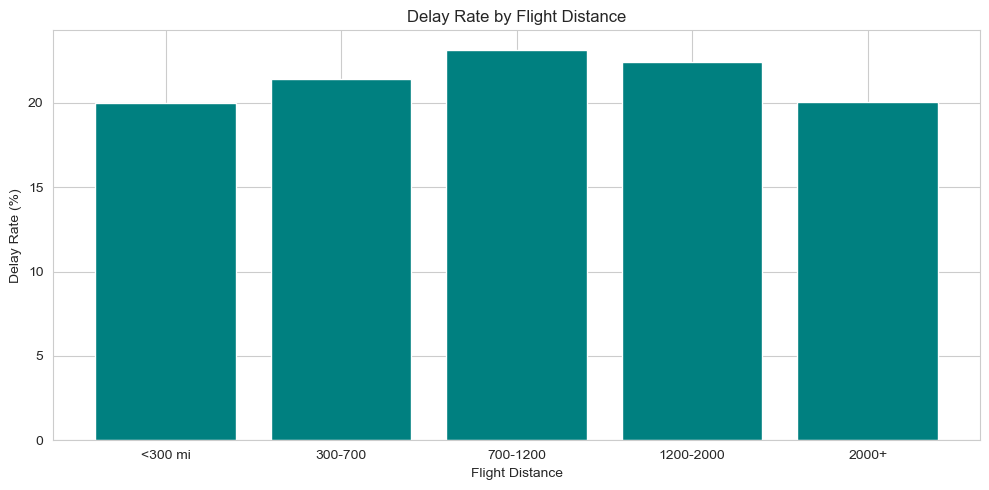

             delay_rate_pct  n_flights
DIST_BUCKET                           
<300 mi               19.96    1056617
300-700               21.38    2423841
700-1200              23.13    2036674
1200-2000             22.39     939866
2000+                 20.04     441739


In [ ]:
bins = [0, 300, 700, 1200, 2000, 6000]
labels = ["<300 mi", "300-700", "700-1200", "1200-2000", "2000+"]
df["DIST_BUCKET"] = pd.cut(df["DISTANCE"], bins=bins, labels=labels)
grouped = df.groupby("DIST_BUCKET", observed=True)
bucket_delay = grouped["DEP_DEL15"].mean() * 100
bucket_count = grouped.size()

plt.figure(figsize=(10, 5))
plt.bar(bucket_delay.index, bucket_delay.values, color="teal")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Flight Distance")
plt.title("Delay Rate by Flight Distance")
plt.tight_layout()
plt.show()

print(
    pd.DataFrame({"delay_rate_pct": bucket_delay.round(2), "n_flights": bucket_count})
)


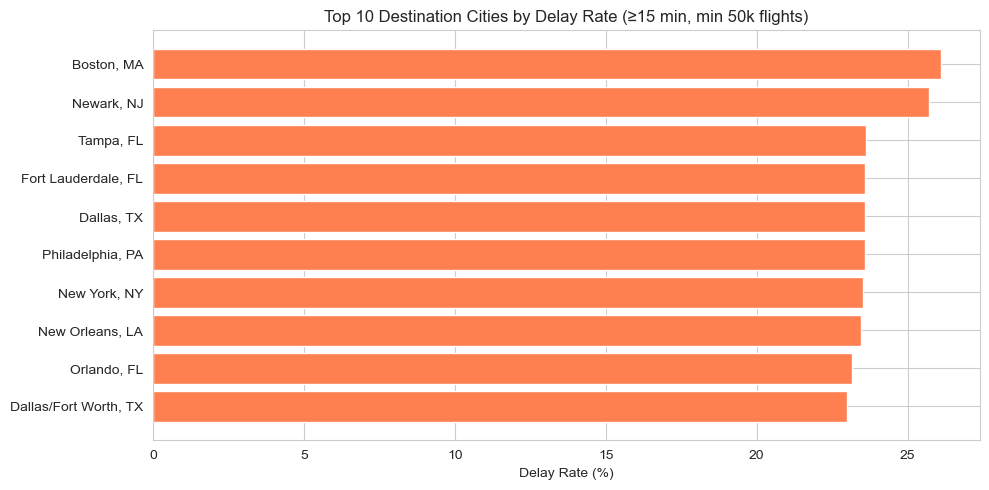

                           mean   count
DEST_CITY_NAME                         
Boston, MA             0.260909  140474
Newark, NJ             0.257088  117279
Tampa, FL              0.236221   78507
Fort Lauderdale, FL    0.235858   86446
Dallas, TX             0.235780   70286
Philadelphia, PA       0.235724   95476
New York, NY           0.235143  234236
New Orleans, LA        0.234407   50280
Orlando, FL            0.231501  158224
Dallas/Fort Worth, TX  0.229939  306912


In [ ]:
dest_stats = df_raw.groupby("DEST_CITY_NAME")["DELAYED"].agg(["mean", "count"])
top_dest = dest_stats[dest_stats["count"] >= 50000].nlargest(10, "mean")

plt.figure(figsize=(10, 5))
plt.barh(top_dest.index, top_dest["mean"] * 100, color="coral")
plt.xlabel("Delay Rate (%)")
plt.title("Top 10 Destination Cities by Delay Rate (≥15 min, min 50k flights)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_dest)


---
## 5. Correlation Matrix

Quick check for multicollinearity among numeric features before modeling.

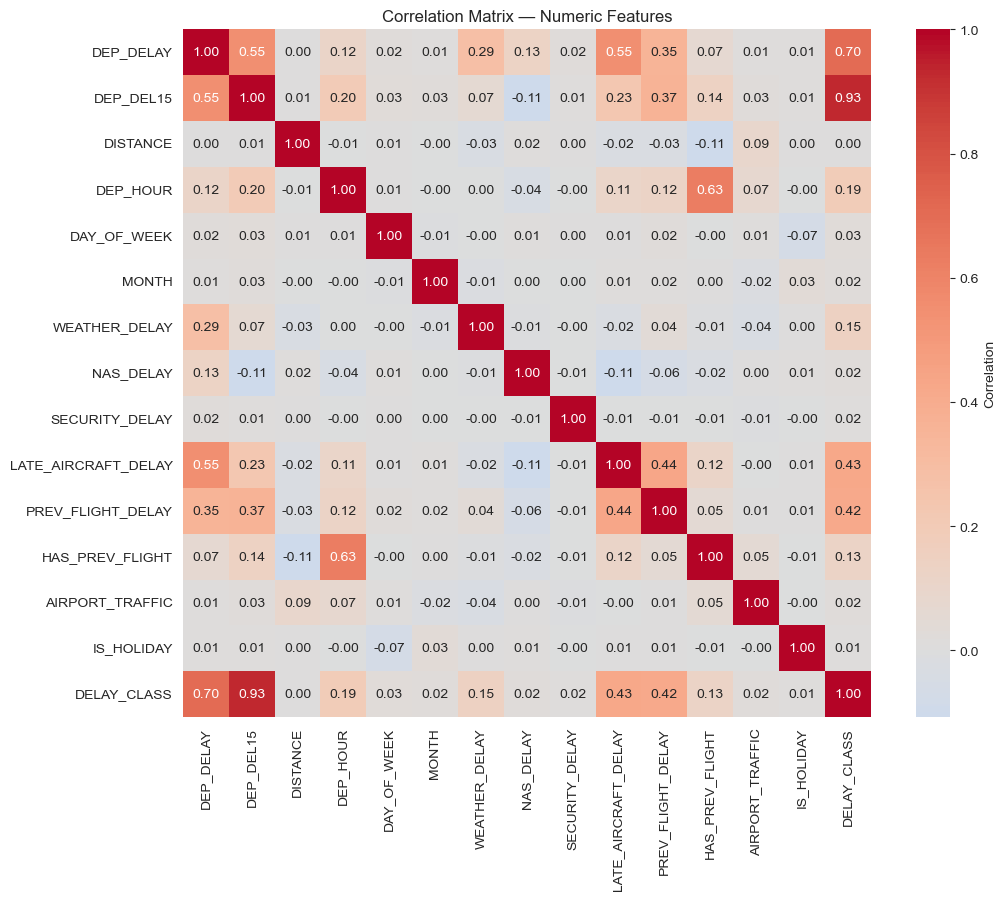

In [ ]:
numeric_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "DISTANCE",
    "DEP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "PREV_FLIGHT_DELAY",
    "HAS_PREV_FLIGHT",
    "AIRPORT_TRAFFIC",
    "IS_HOLIDAY",
    "DELAY_CLASS",
]
avail = [c for c in numeric_cols if c in df.columns]
corr = df[avail].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


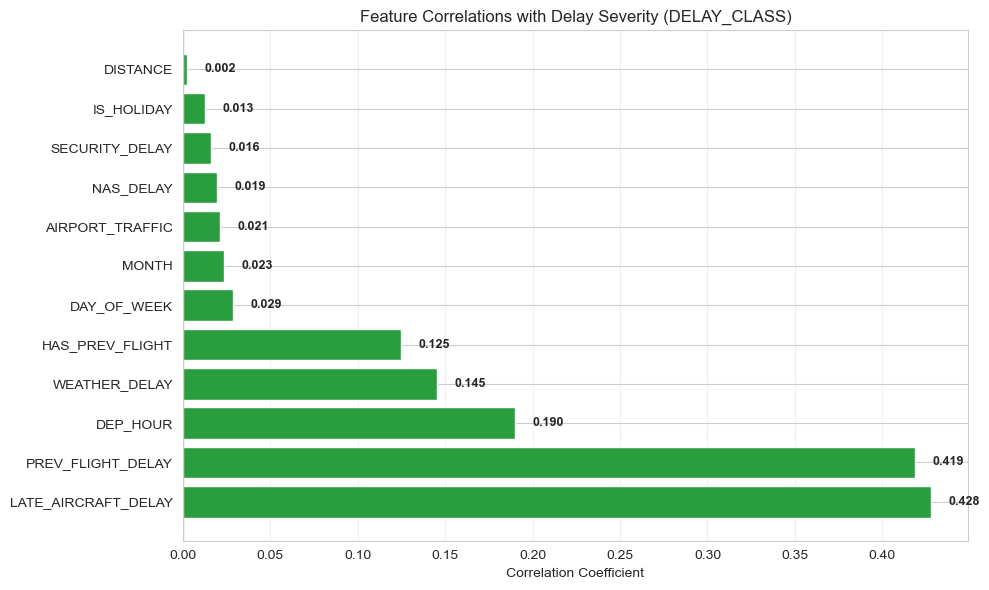

Feature Correlations with DELAY_CLASS (target):
LATE_AIRCRAFT_DELAY    0.428
PREV_FLIGHT_DELAY      0.419
DEP_HOUR               0.190
WEATHER_DELAY          0.145
HAS_PREV_FLIGHT        0.125
DAY_OF_WEEK            0.029
MONTH                  0.023
AIRPORT_TRAFFIC        0.021
NAS_DELAY              0.019
SECURITY_DELAY         0.016
IS_HOLIDAY             0.013
DISTANCE               0.002


In [ ]:
target_corr = (
    corr["DELAY_CLASS"]
    .drop("DELAY_CLASS")
    .drop(["DEP_DELAY", "DEP_DEL15"])
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2a9d3f" if x > 0 else "indianred" for x in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel("Correlation Coefficient")
ax.set_title("Feature Correlations with Delay Severity (DELAY_CLASS)")
ax.axvline(0, color="black", lw=0.8)
ax.grid(axis="x", alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
    ax.text(
        val + (0.01 if val > 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

print("Feature Correlations with DELAY_CLASS (target):")
print(target_corr.round(3).to_string())


---
## 6. Delay Causes Analysis

What are the root causes of flight delays? How do they contribute to total delay minutes?

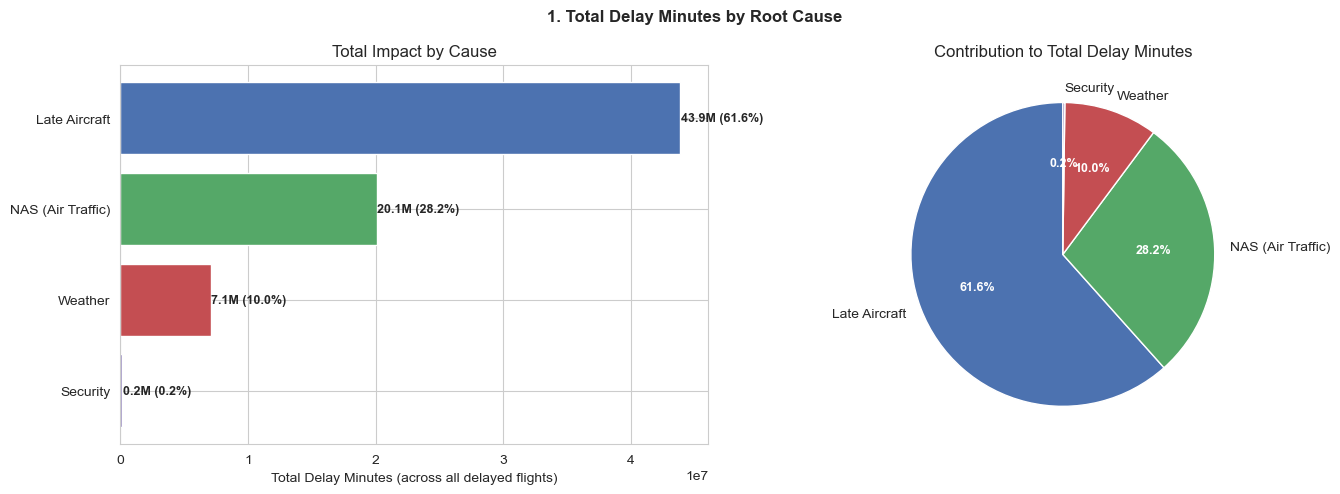

Total delay minutes across all delayed flights: 71,201,967

Delay minutes by cause:
  Late Aircraft.................   43,862,597 min ( 61.6%)
  NAS (Air Traffic).............   20,087,510 min ( 28.2%)
  Weather.......................    7,099,058 min ( 10.0%)
  Security......................      152,802 min (  0.2%)


In [ ]:
df_delayed = df[df["DEP_DELAY"] > 0].copy()

delay_causes = {
    "Weather": df_delayed["WEATHER_DELAY"].sum(),
    "NAS (Air Traffic)": df_delayed["NAS_DELAY"].sum(),
    "Security": df_delayed["SECURITY_DELAY"].sum(),
    "Late Aircraft": df_delayed["LATE_AIRCRAFT_DELAY"].sum(),
}
delay_causes = {k: v for k, v in delay_causes.items() if v > 0}
delay_causes_sorted = dict(
    sorted(delay_causes.items(), key=lambda x: x[1], reverse=True)
)
total_delay_minutes = sum(delay_causes_sorted.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1. Total Delay Minutes by Root Cause", fontsize=12, fontweight="bold")

ax = axes[0]
causes = list(delay_causes_sorted.keys())
minutes = list(delay_causes_sorted.values())
bars = ax.barh(causes, minutes, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_xlabel("Total Delay Minutes (across all delayed flights)")
ax.set_title("Total Impact by Cause")
ax.invert_yaxis()

for bar, minute in zip(bars, minutes):
    pct = (minute / total_delay_minutes) * 100
    ax.text(
        minute + 50000,
        bar.get_y() + bar.get_height() / 2,
        f"{minute / 1e6:.1f}M ({pct:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

causes_list = list(delay_causes_sorted.keys())
minutes_list = list(delay_causes_sorted.values())
colors_pie = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
wedges, texts, autotexts = axes[1].pie(
    minutes_list,
    labels=causes_list,
    autopct="%1.1f%%",
    colors=colors_pie[: len(causes_list)],
    startangle=90,
)
axes[1].set_title("Contribution to Total Delay Minutes")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print(f"Total delay minutes across all delayed flights: {total_delay_minutes:,.0f}")
print("\nDelay minutes by cause:")
for cause, minutes in delay_causes_sorted.items():
    pct = (minutes / total_delay_minutes) * 100
    print(f"  {cause:.<30} {minutes:>12,.0f} min ({pct:>5.1f}%)")


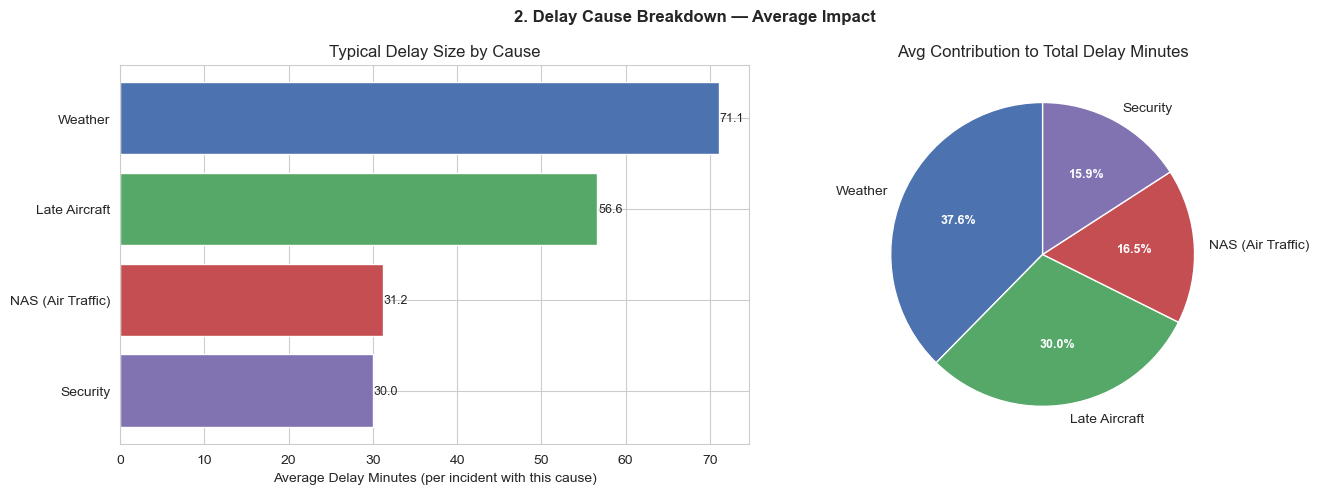


Average delay minutes per incident (when cause is present):
  Weather.......................  71.07 min ( 37.6%)
  Late Aircraft.................  56.64 min ( 30.0%)
  NAS (Air Traffic).............  31.16 min ( 16.5%)
  Security......................  29.96 min ( 15.9%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "2. Delay Cause Breakdown — Average Impact", fontsize=12, fontweight="bold"
)

avg_delays = {}
for cause, col in zip(
    ["Weather", "NAS (Air Traffic)", "Security", "Late Aircraft"],
    ["WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"],
):
    non_zero = df_delayed[df_delayed[col] > 0][col]
    if len(non_zero) > 0:
        avg_delays[cause] = non_zero.mean()

avg_delays_sorted = dict(sorted(avg_delays.items(), key=lambda x: x[1], reverse=True))
avg_causes = list(avg_delays_sorted.keys())
avg_values = list(avg_delays_sorted.values())

bars = axes[0].barh(
    avg_causes, avg_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
)
axes[0].set_xlabel("Average Delay Minutes (per incident with this cause)")
axes[0].set_title("Typical Delay Size by Cause")
axes[0].invert_yaxis()

for bar, val in zip(bars, avg_values):
    axes[0].text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=9,
    )

total_avg_delay = sum(avg_values)
colors_pie = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
wedges, texts, autotexts = axes[1].pie(
    avg_values,
    labels=avg_causes,
    autopct="%1.1f%%",
    colors=colors_pie[: len(avg_causes)],
    startangle=90,
)
axes[1].set_title("Avg Contribution to Total Delay Minutes")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print("\nAverage delay minutes per incident (when cause is present):")
for cause, avg in avg_delays_sorted.items():
    pct = (avg / total_avg_delay) * 100
    print(f"  {cause:.<30} {avg:>6.2f} min ({pct:>5.1f}%)")
